# PCA for shape generation

**Mandatory assignment 2**
This is the second mandatory assignment, to be submitted on LearnIT as a Jupyter Notebook containing your implementation and notes by the deadline specified on [LearnIT](https://learnit.itu.dk/)
. Details on the submission process can be found [here](https://iml.itu.dk/01-about_the_course/01-AboutTheCourse.html)
.
This Assignment contains two parts. Part one is be feasible **after lecture 11**, and the second part **after lecture 12**.
The assignment applies PCA to generate face shapes. The objective is to explore the relationship between points in the latent space and their corresponding representations in the data space.


**Refresh**
The eigenvalue $\lambda_i$ is equal to the variance $\sigma_i^2$ along the direction of its eigenvector $v_i$. This equivalence allows us to use $\lambda_i$ and $\sigma_i^2$ interchangeably. Furthermore observe that the variance is given by $\sigma^2$ and hence the  standard deviation is given by $\sigma$ (standard deviation).
That is:

$$\lambda_i = \sigma_i^2$$
and therefore:

$$\sigma_i = \sqrt{\lambda_i}$$

<div style="float: none; width: 100%; justify-content: start" class="block is-clearfix">


<article class="message">
    <div class="message-body">
        <strong>Overview of mandatory tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#prep">Task 1: Data inspection</a>
            </li>
            <li>
            <a href="#get_pca">Task 2: Evaluate Principal compoenets</a>
            </li>
            <li>
            <a href="#gen">Task 3: Base face</a>
            </li>
            <li>
            <a href="#gen_reflect">Task 4: Base face reflections </a>
            </li>
            <li>
            <a href="#c">Task 5: Investigate variations in latent space</a>
            </li>
            <li>
            <a href="#interpolate">Task 6: Interpolation between two faces</a>
            </li>
            <li>
            <a href="#reflect">Task 7: Reflection</a>
            </li>
            <li>
            <a href="#correlation_eigen">Task 8: Eigenvalues and eigenvectors of correlat…</a>
            </li>
            <li>
            <a href="#Dimensionality_red">Task 9: Out of distribution generation</a>
            </li>
        </ul>
    </div>
</article>



</div>


**Important**
Solve the Introduction to PCA
 exercise part 1 **before starting on part 1 of this assignment**. 

# Part 1
## Data
The dataset used for the assigment consist of 120 landmarks (2D points) of faces (data space). A face consists of 73 (x,y)-coordinate pairs, i.e. 146 featues in total.

---
**Task 1 (easy): Data inspection👩‍💻**
1. Run the cell below to load libraries, the data and to  visualize the first 6 sample face shapes.


---

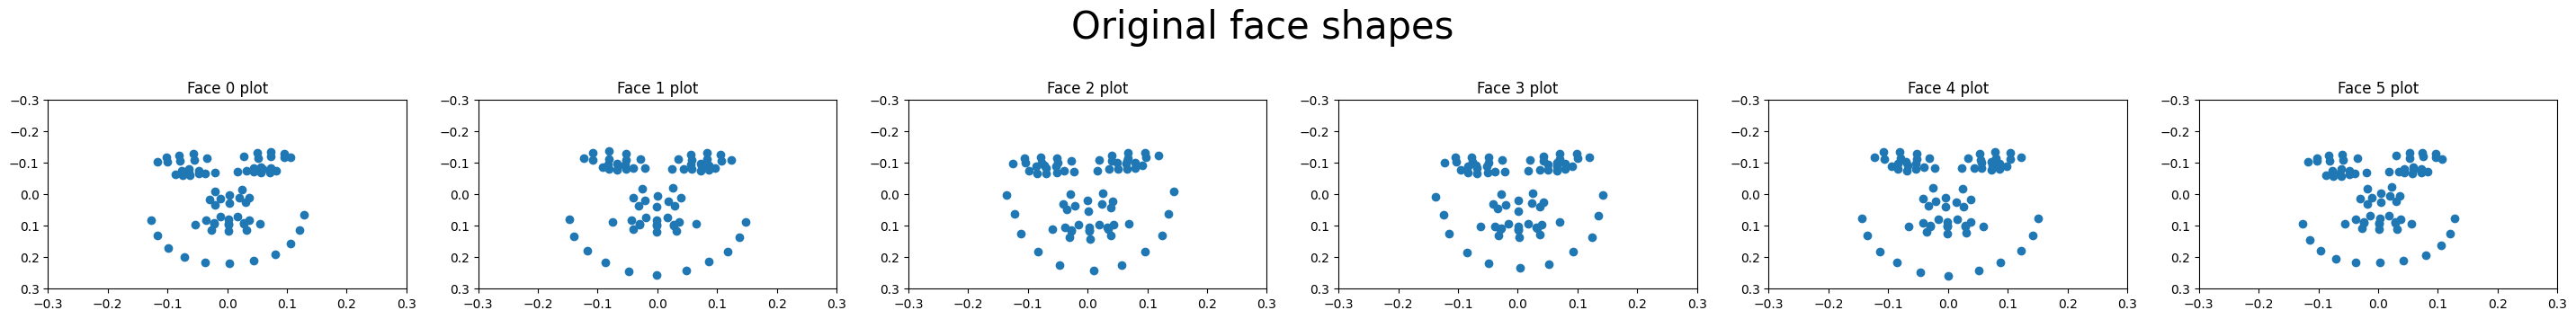

In [1]:
## Importing libraries
import matplotlib.pyplot as plt
import numpy as np
import scipy
from pca_utils import *
import os
from glob import glob

path = './db/'
shapes, _ = face_shape_data(path)

plot_many_faces(shapes[:6],"Original face shapes")

## PCA implementation
The following tasks are about using the implementation of PCA from the in-class exercise on the face shape dataset. 

---
**Task 2 (easy): Get principal compontents👩‍💻**
1. Complete the `get_principal_components`
 function so that it returns all principal components `comp`
, eigenvalues `val`
 and mean vector `mu`
, given the dataset `shapes`
.
2. Use the `get_principal_components`
 function to calculate the principal components (`comp`
) for the face dataset.
3. Implement the function `transform_to_latent_space`
  according to the comments in the cell below using  $\mathbf{a} = \mathbf{\Phi_k}^\top(\mathbf{x}-\mathbf{\mu})$ .
4. Implement the function `transform_from_latent_space`
  according to the comments in the cell below using $x  = \mathbf{\Phi_k} \mathbf{a} + \mathbf{\mu}$ . 
5. Run the cell below to map $6$ face shapes to the latent space and back to the original data space. The `plot_many_faces`
 function is used to display both the original and the restored face shapes.
6. Visually inspect the figures and describe the reconstruction error.


---

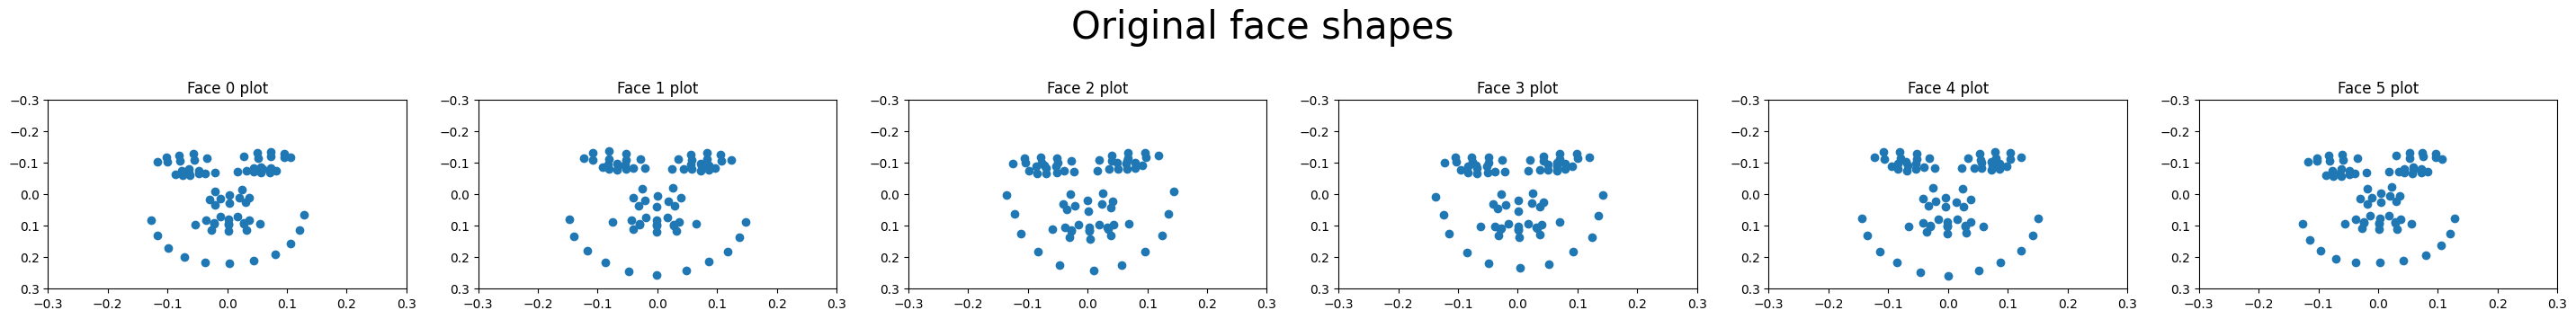

/Users/jonasson/.pyenv/versions/3.12.2/envs/intro_to_ml/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/jonasson/.pyenv/versions/3.12.2/envs/intro_to_ml/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


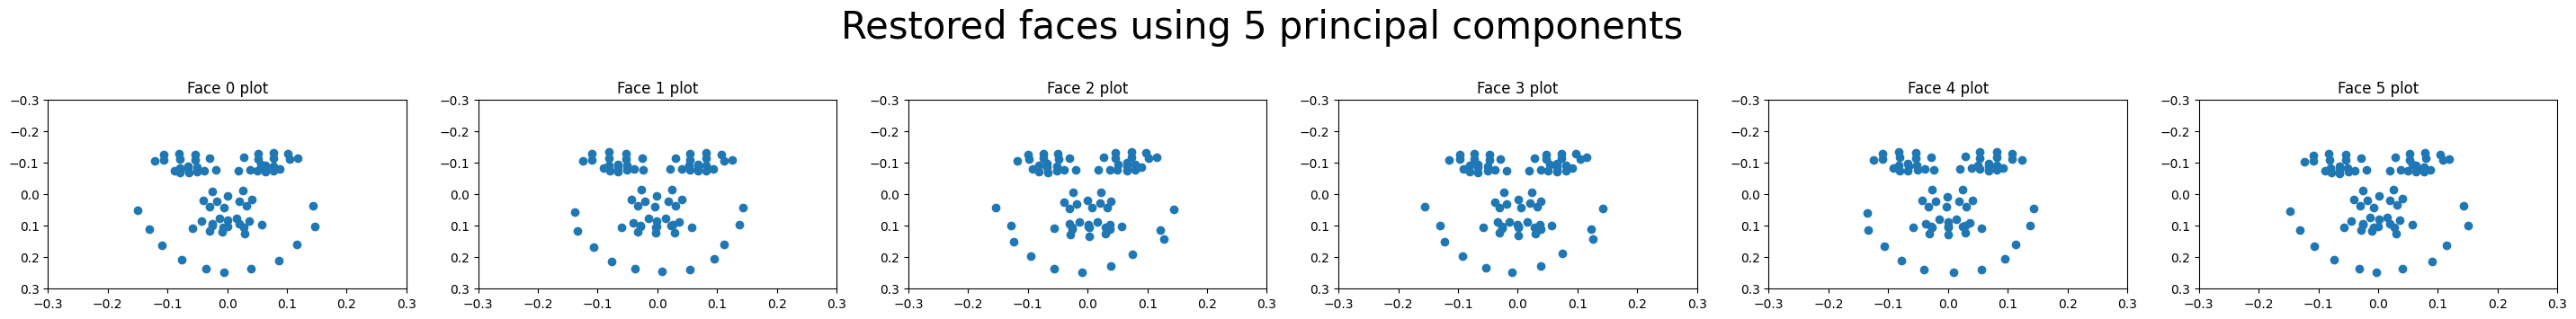

In [2]:
# 1
def get_principal_components(X):
    """Calculates principle components for X.

    Args:
        X: The dataset. An NxD array were N are the number of samples and D are
        the number of features.

    Returns:
        Tuple (components, eigenvalues, mu) where components is a DxD matrix of
        principle components, eigenvalues is a D-element vector of
        corresponding eigenvalues, and mu is a D-element array containing the mean
        vector.
    """
    mu = X.mean(axis=0) # mean over the data point axis to get mean of each feature
    norm = X - mu # subtract mean from all points to normalize around 0
    cov = 1 / (norm.shape[0] - 1) * np.matmul(norm.T, norm) # Calculate covariance as per formula
    ##cov = np.cov(norm) # alternative covariance from numpy instead of written out formula
    e_val, e_vec = np.linalg.eig(cov) # use numpy library to get eigenvalues and eigenvectors -> returns some complex numbers
    # sorting in decreasing order
    temp = list(zip(list(e_val), list(e_vec)))
    temp.sort(reverse= True, key=lambda x : x[0])
    e_val, e_vec = np.array([n[0] for n in temp]), np.array([n[1] for n in temp])

    return (e_vec, e_val, mu)


# 2, 3 and 4
# Get the principal components for the dataset and transform the faces to feature space.
comp, val, mu = get_principal_components(shapes)

# selecting 5 components 
n_components = 5

# 5
def transform_to_latent_space(X, principle_components, mu):
    """Transforms X to an k-dimensional space where k is the number of
    principle_components.

    Args:
        X: The dataset. An NxD array were N are the number of samples and D are
        the number of features.
        principle_components: An Dxk matrix containing the principle
        components.
        mu: A D-element array containing the mean vector.

    Returns:
        A Nxk array describing the transformed data.
    """
    # needed an extra transpose to make the shapes work in the multiplication order given by the formula
    # reason: in the formula for one datapoint the point is a column vector, but in X datapoints are represented as rows 
    # the multiplication is therefore as follows: Dxk, NxD converted to kxD, DxN -> kxN. Final convertion to Nxk as specified.
    return np.matmul(principle_components.T, (X - mu).T).T
    
# 6  
def transform_from_latent_space(v, principle_components, mu):
    """Reverses the dimensionality reduction of v, a Nxk matrix where
    k is the number of principle components. The result is a NxM matrix.

    Args:
        v: The transformed dataset with size Nxk.
        principle_components: An Dxk matrix containing the principle
        components.
        mu: A Mx1 matrix containing the mean vector.

    Returns:
        An NxD array reconstruction of the original feature vectors X.
    """
    # Needed some extra transposes to make the shapes work compared to the formula
    # reason: for the multiplication to succeed wit shapes Dxk, Nxk, we need to pair up the ks -> Dxk, kxN
    # result: DxN matrix. Transpose to make the result NxD as specified.
    t = np.matmul(principle_components, v.T).T 
    return t + mu

    
# 7     
used = comp[:, :n_components]

# transforming and reconstructing the 6 first faces in the dataset
plot_many_faces(shapes[:6],"Original face shapes")
transformed = transform_to_latent_space(shapes[:6], used, mu)
restored = transform_from_latent_space(transformed, used, mu)
plot_many_faces(restored,"Restored faces using 5 principal components")

### 2.6 Reflections

some of the faces are similar and some of them have become twisted - for example the third face where the dots indicating thw jawline are not continuous but have 2 dots almost on top of each other. Generally, the curves seem less smooth and more "raggetty" in the transformed version



---
**Task 3 (easy): Evaluate Principal compoenets💡**
1. How many components are needed to retain $50\%$, $60\%$, $80\%$, $95\%$ of the total variation?
2. Seting $k=5$ components. How much of the total variance is retained?
3. Visually inspect the figures and describe the reconstruction error. **(isn't this same as 2.6? see answer above :D)**


---

In [3]:
# 1 
# val is the eigenvalue array
total_var = float(val.sum())
proportional_var = [float(n / total_var) for n in val]
cum_prop_var = [float(sum(val[:i+1]) / total_var) for i in range(len(val))]

def find_k(cum_prop_var, pct):
    k = 1
    while cum_prop_var[k-1] < pct:
        k += 1
    return (k, cum_prop_var[k-1])

print(f"Components to retain 50%: {find_k(cum_prop_var, 0.5)}") # (2, 0.6490960275876175)
print(f"Components to retain 60%: {find_k(cum_prop_var, 0.6)}") # (2, 0.6490960275876175)
print(f"Components to retain 80%: {find_k(cum_prop_var, 0.8)}") # (4, 0.8283508938665491)
print(f"Components to retain 95%: {find_k(cum_prop_var, 0.95)}") # (8, 0.9525677808087711)

# 2
print(f"Variance retained by 5 components: {(5, cum_prop_var[5])}") # 0.91175061178406

Components to retain 50%: (2, 0.6490960275876175)
Components to retain 60%: (2, 0.6490960275876175)
Components to retain 80%: (4, 0.8283508938665491)
Components to retain 95%: (8, 0.9525677808087711)
Variance retained by 5 components: (5, 0.91175061178406)


/var/folders/5p/hd3qyvgs2yj3fc69b966hnfc0000gn/T/ipykernel_28430/4080003861.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  total_var = float(val.sum())
/var/folders/5p/hd3qyvgs2yj3fc69b966hnfc0000gn/T/ipykernel_28430/4080003861.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  proportional_var = [float(n / total_var) for n in val]
/var/folders/5p/hd3qyvgs2yj3fc69b966hnfc0000gn/T/ipykernel_28430/4080003861.py:5: ComplexWarning: Casting complex values to real discards the imaginary part
  cum_prop_var = [float(sum(val[:i+1]) / total_var) for i in range(len(val))]



**Important**
Solve the Introduction to PCA
 exercise part 2 **before starting on part 2 of this assignment**. 

# Part 2
## Using PCA for shape generation
The principal components can be used to generate new samples $\mathbf{x}$ in data space by transforming a point in latent space according to 
$$\mathbf{x} = \Phi_{k} a + \mu$$
 where $\Phi_{k}$ is the matrix of k eigenvectors, $\mathbf{a}\in\mathbb{R}^{k}$ is a vector in latent space, and $\mu\in\mathbb{R}^{D}$ is the mean vector of the original data features in  the data space.

$$

{\Phi_k} = \begin{bmatrix} | & | & & | \\ {v}_1 & {v}_2 & \cdots & {v}_k \\ | & | & & | \end{bmatrix}

$$
The variance of the data in a given direction can be used to constrain the values of the elements of the vector $\mathbf{a}$ in latent space, assuming that the data follows a (multivariate) normal distribution. In a multivariate normal distribution each direction $v_i$ is also normally distributed. Each element $a_i$ can be constrained to be within the observed variance in direction $v_i$. The variance $\sigma_i^2$ in the direction of $v_i$ is given by the eigenvalue $\lambda_i$, so the standard deviation is  $\sigma_i = \sqrt{\lambda_i}$.
In a 1D normal distribution (with mean $\mu$ and standard deviation $\sigma$), the area under the Gaussian curve between $\pm 3\sigma$ contains $99.7\%$ of the data (see [Figure 1](#normal) ). Thus, constraining each element $a_i$ to the interval $[-3\sigma_i, 3\sigma_i]$ will cover $99.7\%$ of the variance in the direction of $v_i$. 
<div class="has-text-centered">
<figure class="image is-inline-block" id="normal">

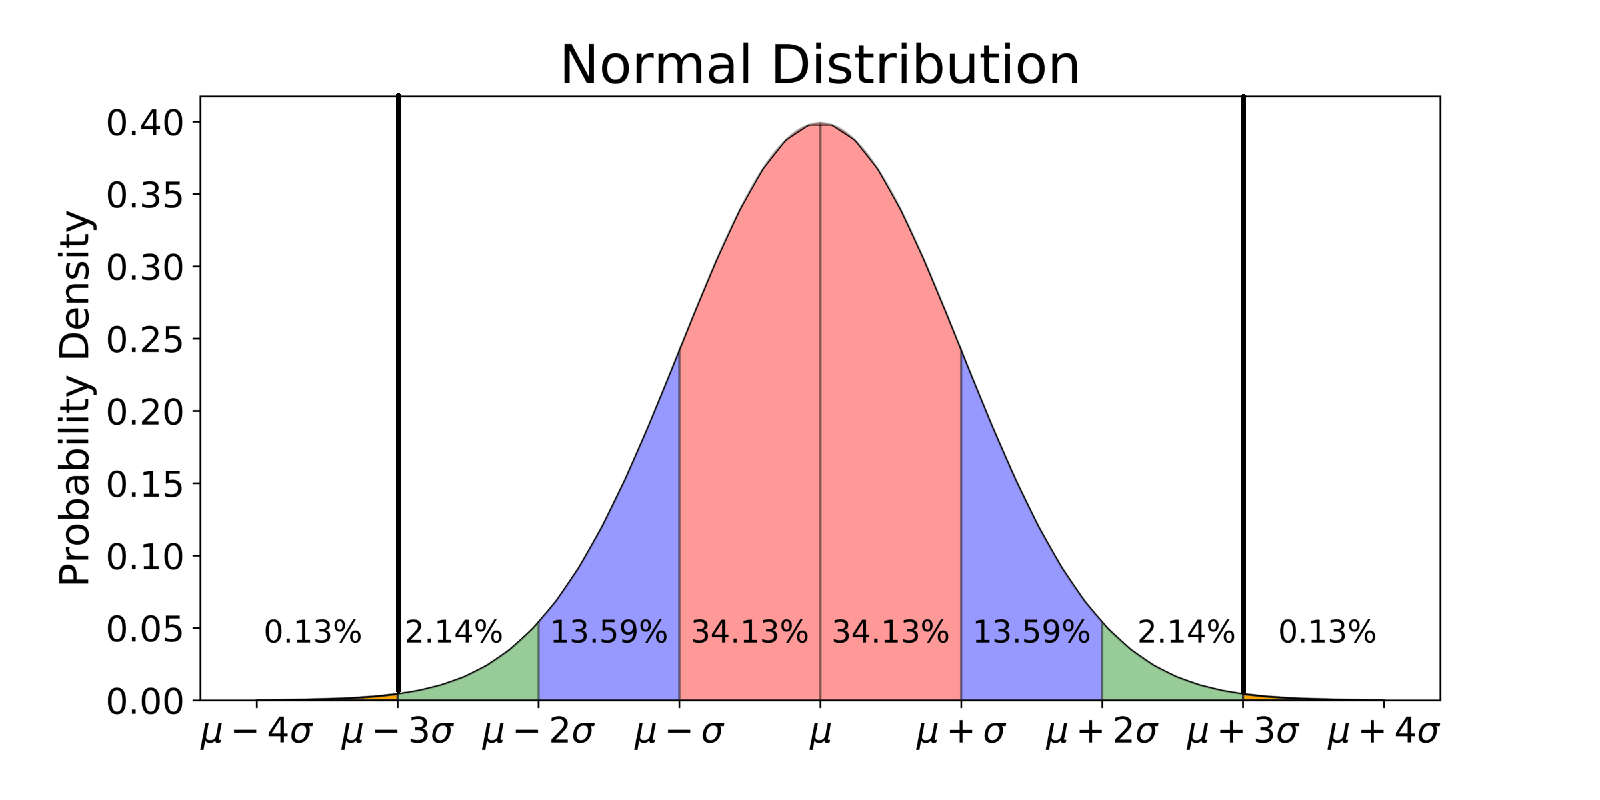

<figcaption class="figure-caption has-text-centered">Figure 1: Illustration of a normal distribution. The vertical lines mark the region covering $99.7\%$ of the variance. The shaded regions indicate the
area of the distribution covered by 1, 2, 3, and 4, standard deviations
($\sigma$) respectively.
</figcaption>
</figure>
</div>

---
**Task 4 (medium): Base face👩‍💻**
1. **Generate vectors:** run the cell below to create the zero vector in latent space, i.e. $\mathbf{a} = [0, 0, \dots, 0]\in\mathbb{R}^5$.
2. **Shape generation:** use $\mathbf{x} = \mathbf{\Phi} \mathbf{a} + \mathbf{\mu}$ to generate a face (vector in real space) from the vector $\mathbf{a}$. Use the `plot_face`
 function to visualise the generated face.
3. Change the elements of $\mathbf{a}$ to the values below, where $\lambda_i$ is the i-th eigenvalue and plot the resulting shapes for each modification:    - $\mathbf{a} = [\sqrt{\lambda_1},0, 0, 0, 0]$ $\in\mathbb{R}^5$? 
    - $\mathbf{a} = [0,-3\sqrt{\lambda_2}, 0, 0, 0]$ $\in\mathbb{R}^5$?




---

In [4]:
# handy translation

eigenvectors = comp
eigenvalues = val
mean = mu

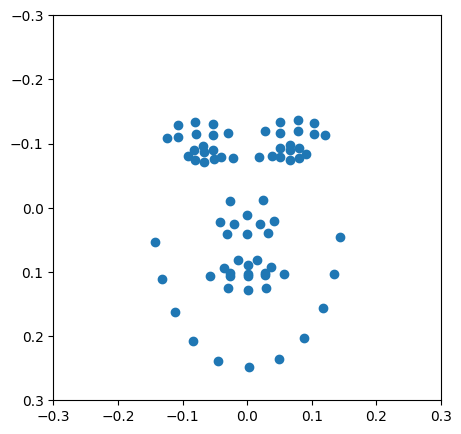

In [5]:
a = np.array([0,0,0,0,0])

def generate_face(a):
    Fi_5 = eigenvectors[:,0:5]
    x = np.matmul(Fi_5, a) + mean 

    plot_face(x)

generate_face(a)

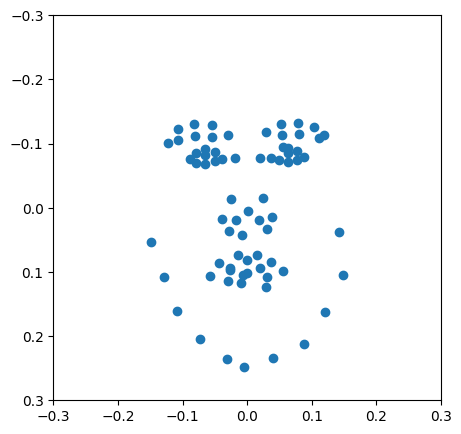

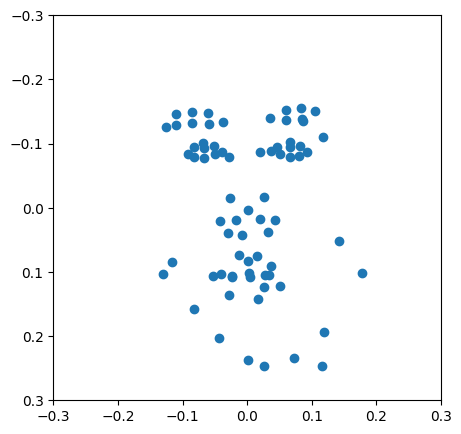

In [6]:
#3

a1 = np.array([np.sqrt(val[0]),0,0,0,0])
a2 = np.array([0,-3*np.sqrt(val[1]),0,0,0])

generate_face(a1)
generate_face(a2)


---
**Task 5 (medium): Base face reflections 💡**
1. Use $\mathbf{x} = \Phi_{k} a + \mu$ to explain what the vector $a \in R^5$ represents if     - $\mathbf{a}= [0,0,0,0,0]$?
    - $\mathbf{a} = [\sqrt{\lambda_1},0, 0, 0, 0]$? 
    - $\mathbf{a} = [0,-3\sqrt{\lambda_2}, 0, 0, 0]$?


2. Describe what face is generated and why.


---

In [7]:
# a0 represents the "base face", the face generated by taking exactly the mean of the first 5 components and disregarding the rest. It can be interpretated as the most average face for this k.

# a1 represents a face with the average value in the components 2..5, with feature 1 one standard deviation to the right from the center. The face generated is very similar to the base case, 
# with slight differences mostly in the nose area.

# a2 represents a face with average values for components 1, 3..5, but three standard deviations to the left for feature 2. The face generated is therefore quite distorted, as landing three
# standard deviations from the mean is very unlikely (the mouth looks very ragged).

## Investigating principal components
The following tasks are about investigating properties of principal components.

---
**Task 6 (medium): Investigate variations in latent space👩‍💻**
1. **Varying the 1st component:** Let $\mathbf{a} \in \mathbb{R^5}$ be a vector in the latent space. Generate 5 different vectors where only the first element, $a_1$, varies, while the remaining elements, $a_2, a_3, a_4, a_5$, are set to 0. Use `np.linspace`
 to generate 5 evenly spaced values for $a_1$ in the interval $[-3\sigma_1, 3\sigma_1]$. For each value of $a_1$, generate a corresponding face and display all 5 faces in a plot. 

2. **More components:** Do the same for each of the remaining four components, i.e. $a_2$-$a_5$ leaving the others as 0. 

3. **Component analysis:** Describe how each principal component changes the face shape (for example, the first component may change the length of the face). 



---

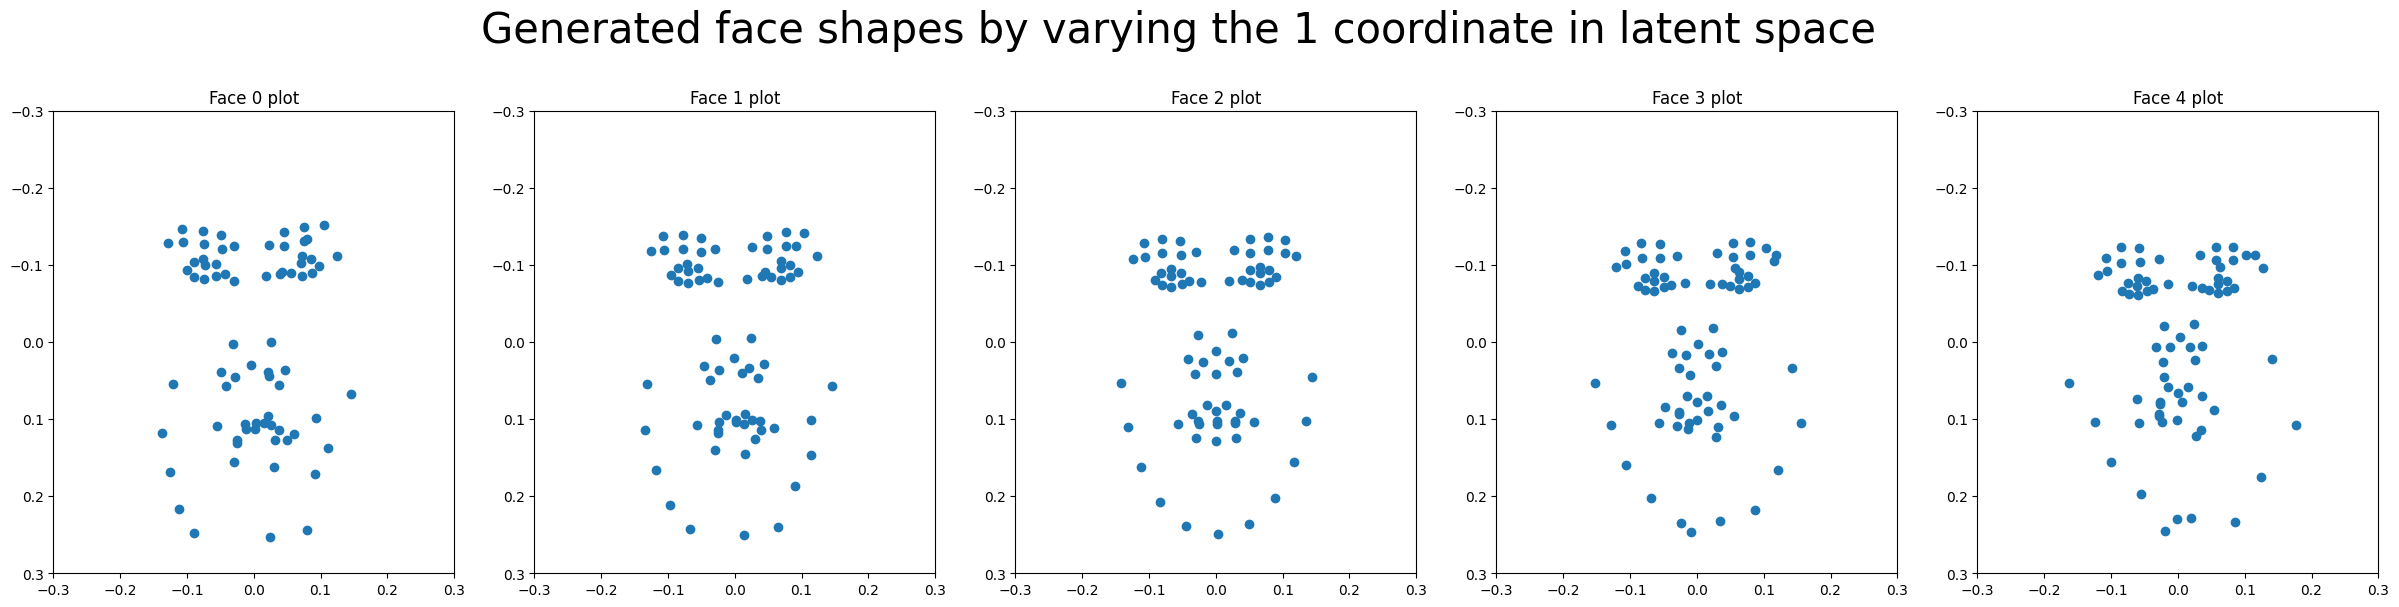

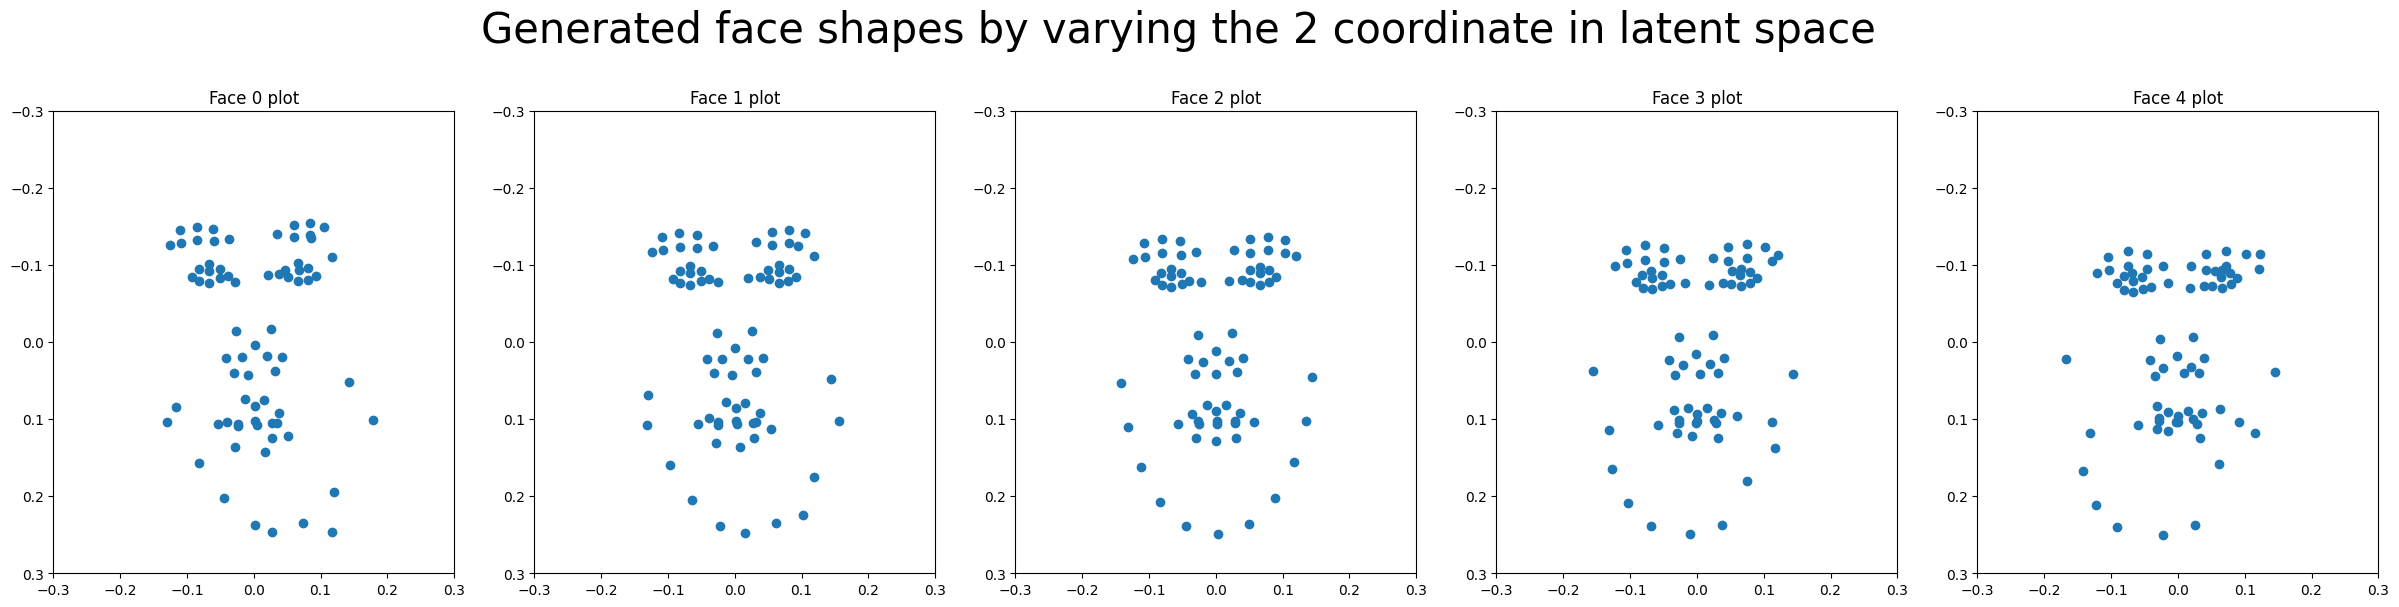

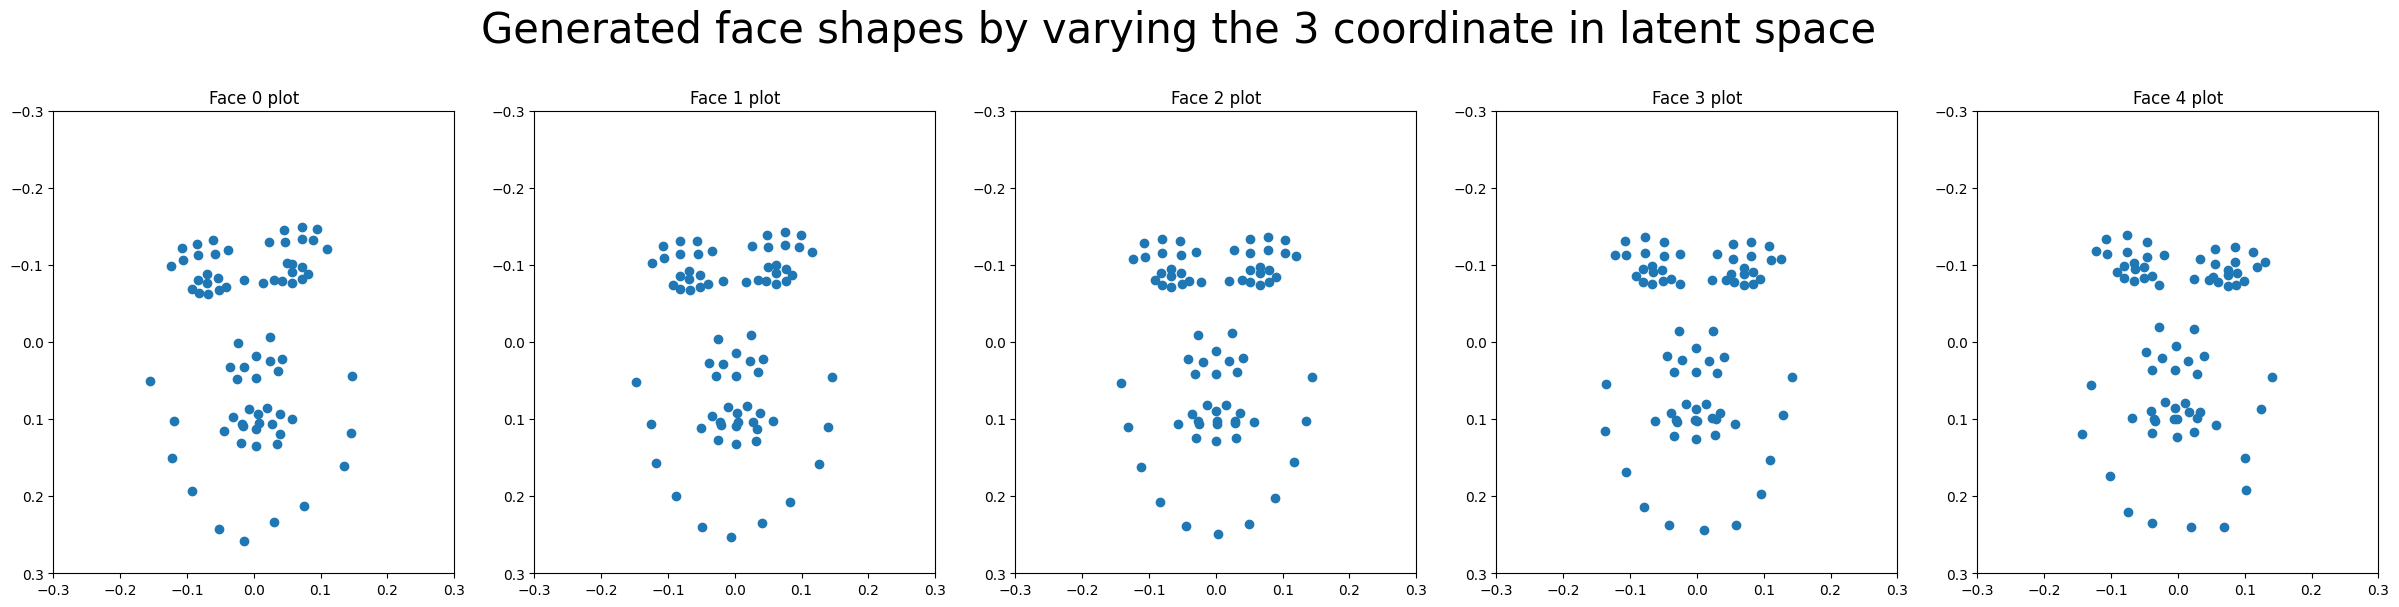

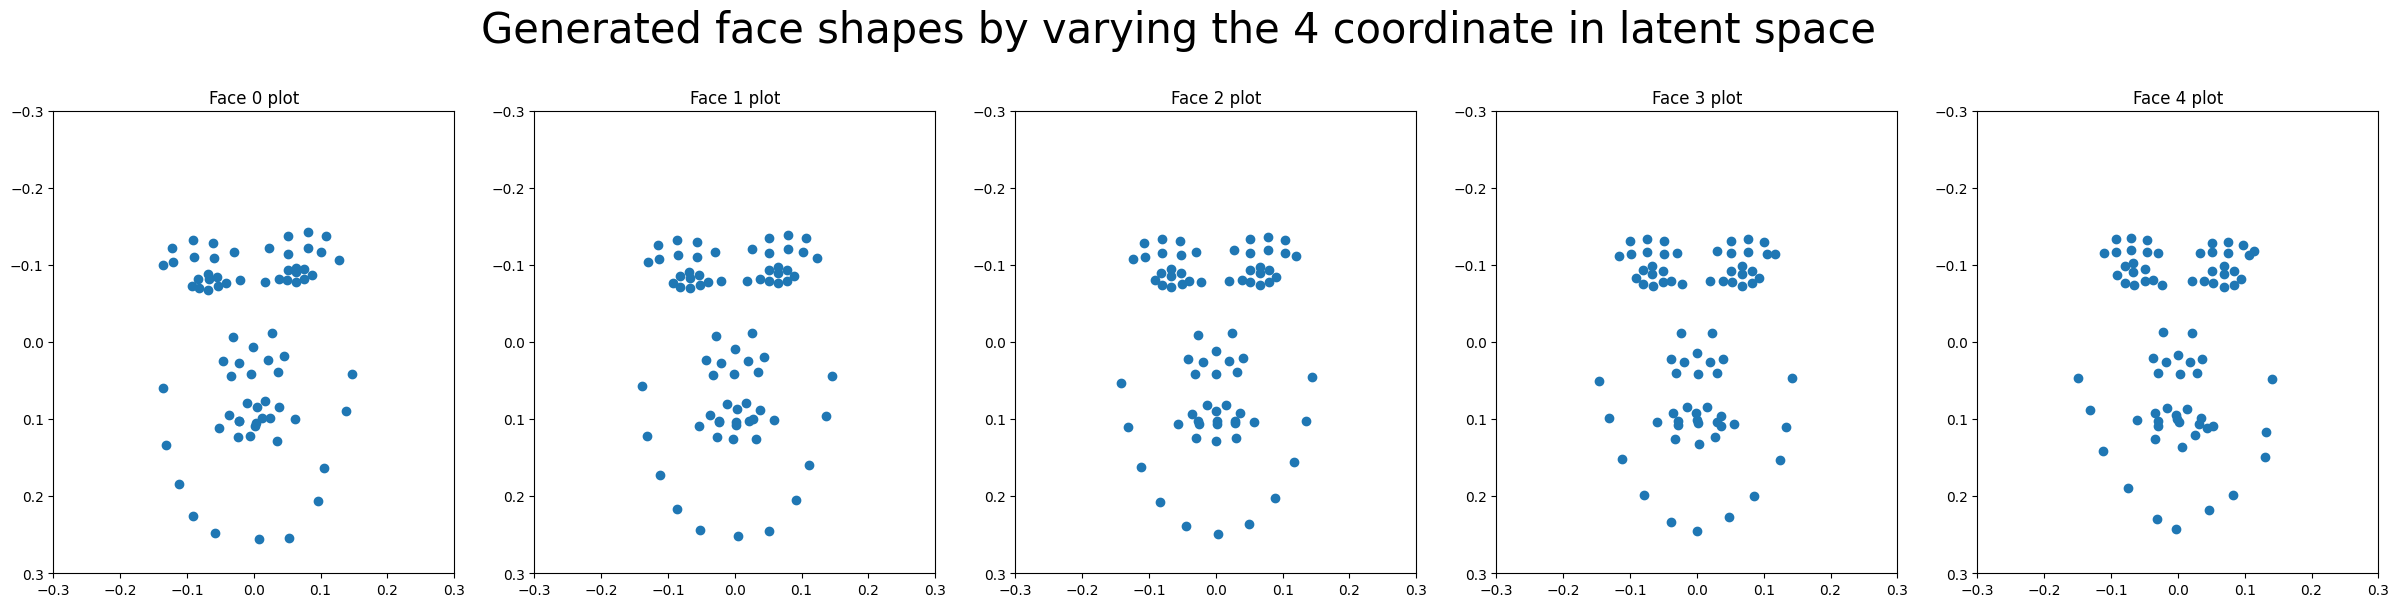

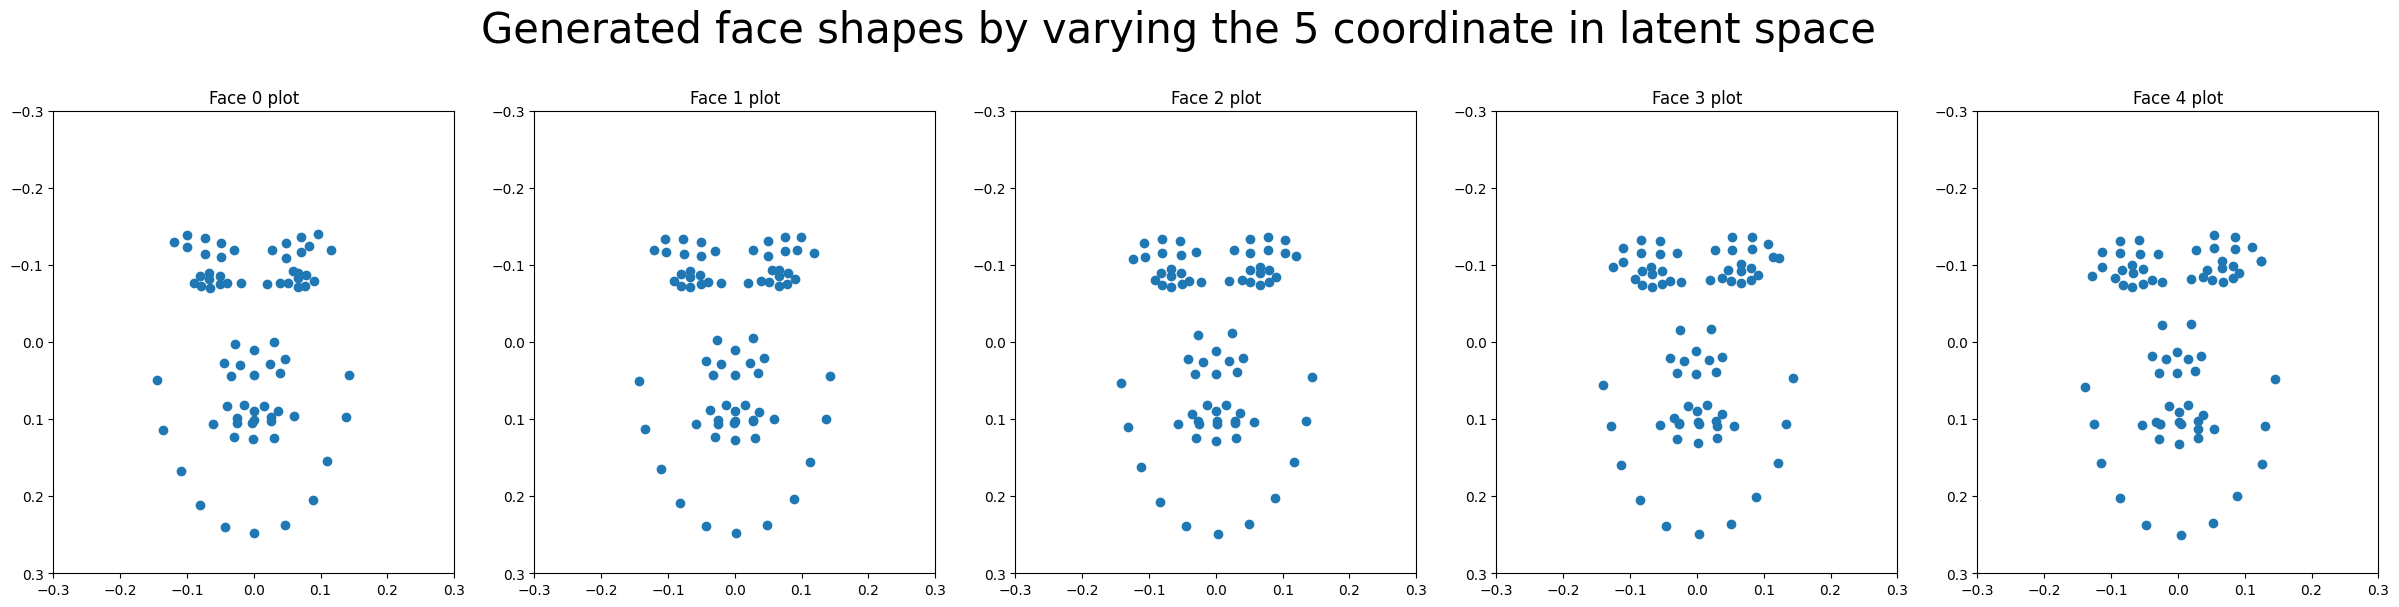

In [8]:
Fi_5 = eigenvectors[:,0:5]

def generate_component_faces(k):
    faces = []
    std = np.sqrt(eigenvalues[k]) # std/eigvalue for the kth PC
    values = np.linspace(-3*std, 3*std, num=5)
    a = [0, 0, 0, 0, 0]
    for i in range (5):
        a[k] = values[i]
        x = np.matmul(Fi_5, a) + mean 
        faces.append(x)
    
    return faces



for k in range (5):
    gen_shapes = generate_component_faces(k)
    plot_many_faces(gen_shapes,f"Generated face shapes by varying the {k+1} coordinate in latent space")

In [9]:
# the 1st coordinate seems to be responsible most of all for the shape of the mouth, with variation to the right "stretching" it downwards, and to the left "compressing" it upwards 
# However, a good argument could also be made that the 1st componenets conveys "emotion", with more agreeable faces with positive variation, and more disagreeable ones with negative variation

# the 2nd coordinate seems to be responsible for the overall compactness of the face, with all points being more scattered with negative variation, and heavily clustered with positive variation

# the 3rd coordinate seems to rotate the face, clockwise for negative variation, counterclockwise for positive variation 

# the 4th coordinate seems to control in what direction a person is looking, modifying the face accordingly.
# looking to the right (from the face perspective) with negative variation, looking to the left with positive variation. 

# the 5th coordinate seems to control the eyebrow shape - with more angry faces with positive variation, and more relaxed one with negative variation

## Interpolating between shapes
The following example shows how to interpolate two vectors.


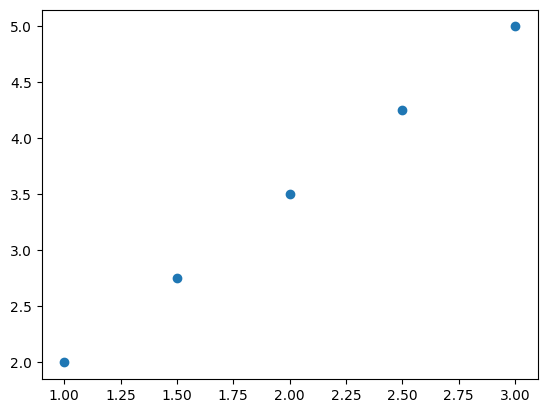

In [10]:
# #Template for doing interpolation between two (2D)- points 
d = np.linspace(np.array([1, 2]), np.array([3, 5]), num=5)
plt.scatter(d[:, 0], d[:, 1])


---
**Task 7 (medium): Interpolation between two faces👩‍💻**
**Shape Interpolation:**
1. Select points $\mathbf{a}$ and $\mathbf{b}$ in latent space (paying attention to the Gaussian constraints) and generate the faces.
2. Use `np.linspace`
 to generate 6 evenly spaced points that interpolate between two vectors, $\mathbf{a}$ and $\mathbf{b}$, in the latent space. Plot the resulting faces. 
3. Select $\mathbf{a}$ and $\mathbf{b}$ such that:    - $\mathbf{a}$ = $[-3\lambda_1,0,-3\lambda_3,0,0]$ and $\mathbf{b}$ = $[3\lambda_1,0,3\lambda_3,0,0]$.
    - $\mathbf{a}$ = $[0,5\lambda_2,0,0,0]$ and $\mathbf{b}$ = $[0,-5\lambda_2,0,0,0]$.
    - the generated shapes represent a smile.




---

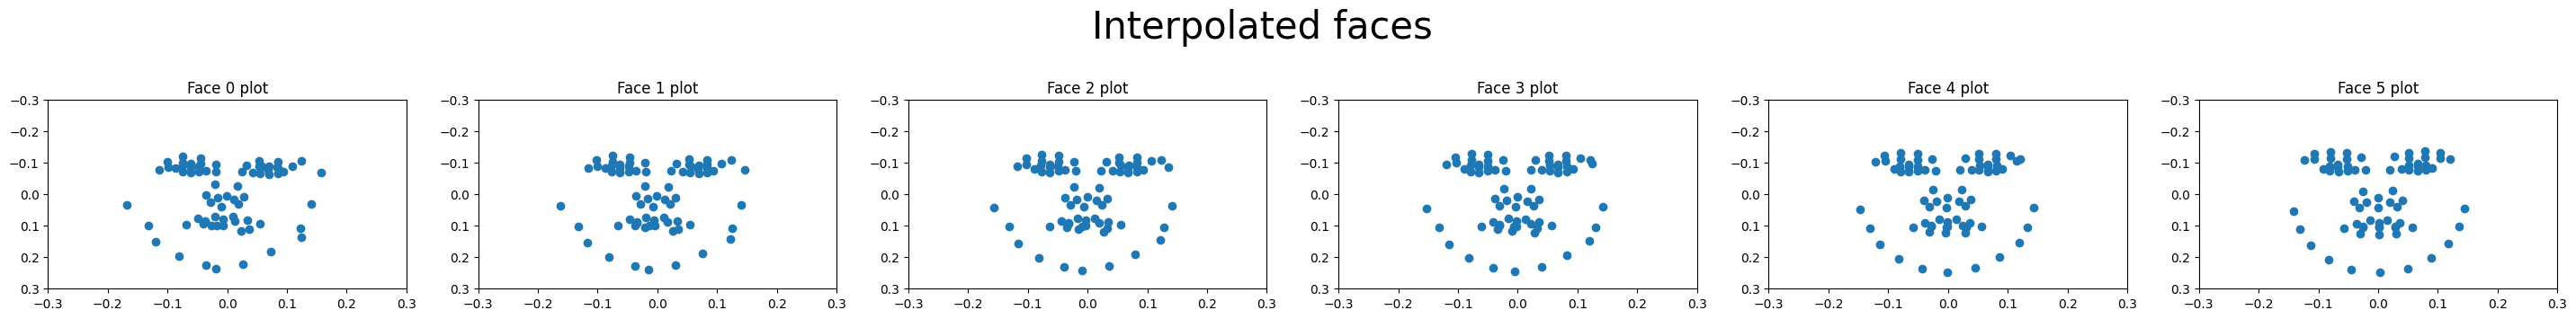

In [11]:
def interpolate(a, b):
    faces = []
    inter = np.linspace(a, b, num=6)
    for i in inter:
        x = np.matmul(Fi_5, i) + mean 
        faces.append(x)
        
    plot_many_faces(faces, "Interpolated faces")

# initial 
a = np.sqrt([val[0], val[1], val[2], val[3], val[4]]) * 2
b = np.sqrt([-val[0], -val[1], -val[2], -val[3], -val[4]]) * 2

# required: not sure why, but if the values are not sqrt() the faces a, b seem identical, and oddly similar to the base face.
# is that outside of the Gaussian constraints, and therefore rolling back to the mean? 
# a = [-3*val[0], 0, -3*val[2], 0, 0]
# b = [3*val[0], 0, 3*val[2], 0, 0]

# a = [0, 5*val[1], 0, 0, 0]
# b = [0, -5*val[1], 0, 0, 0]

# smiling

# a = np.sqrt([0, 0, val[2], 0, 0])
# b = np.sqrt([3*val[0], 0, 3*val[2], 0, 0])

interpolate(a, b)


---
**Task 8 (medium): Reflection💡**
Describe and reflect on the results obtained from this assignment, the exercises and the in-class exercises. Answer the following questions:
1. **Behaviour:** Explain why, a set of points interpolated on a line in latent space corresponds to a sample on a line in data space using $x = \Phi\mathbf{a} + \mu$. 
2. How well can a few principal components reproduce the samples? What happens with the generated data when the number of components $k$ is changed to 1,3,9, or 15?


---

In [12]:
#1 

# Because of the mapping defined before between the latent space and the data space, we can infer that any value generated in the latent space will have a corresponding face in the data space.
# If we generate points on a line between points a and b, it's natural to expect that in the data space, we have just generated faces "between" faces a and b 

#2
# The componenets can (quite surprisingly) reproduce the samples well even for small values of k. While k=1 might not be enough to reliably reproduce a face,
# even if it alone accounts for 60% of the variance, k=3 can already do a surprisingly good job. That's the essence of PCA - we can reduce the initial 146 dimensions into mere 3, and preserve
# most of the information by analyzing the information about data spread. 
# For k=9 and k=15, the quality of the reproduced samples would increase, however, it would increase much less so from 9->15 than from 1->3 or 3->9. 

## Last section - optional
This final section includes three tasks that offer valuable insights into the application of PCA, however completing this section is optional.

---
**Task 9 (medium): Eigenvalues and eigenvectors of correlation matrix _(optional)_👩‍💻💡**
1. Implement the function `get_principal_components_correlation`
 according to the comments in the cell below.
2. Use the provided code to display the eigenvalues of the correlation matrix.
3. How do the eigenvalues obtained from the covariance matrix compare to those from the correlation matrix in terms of magnitude and the variance each principal component explains? What does this reveal about the effect of feature scaling on PCA results?


---

In [13]:
def get_principal_components_correlation(X):
    """Calculates principal components using the correlation matrix for X.

    Args:
        X: The dataset. An NxD array where N are the number of samples and D are
        the number of features.

    Returns:
        Tuple (components, eigenvalues, mu) where components is a DxD matrix of
        principal components, eigenvalues is a D-element vector of
        corresponding eigenvalues, and mu is a D-element array containing the mean
        vector.
    """
    # Standardize the data
    
    # Compute the correlation matrix
    
    # Sort the eigenvalues and eigenvectors in descending order
    
    return ....

# Use the function on the shapes data
eigenvectors_corr, eigenvalues_corr, mu_corr = get_principal_components_correlation(shapes)

# Optionally, plot the eigenvalues to see their distribution
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(eigenvalues_corr) + 1), eigenvalues_corr, 'o-', linewidth=2)
plt.title('Eigenvalues of the Correlation Matrix')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

variance_explained = eigenvalues_corr / np.sum(eigenvalues_corr)
cumulative_variance_explained = np.cumsum(variance_explained)

# Plot cumulative variance explained
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance_explained) + 1),
         cumulative_variance_explained, 'o-', linewidth=2)
plt.title('Cumulative Variance Explained by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.axhline(y=0.95, color='r', linestyle='--')  # Line to indicate 90% variance
plt.grid(True)
plt.show()

SyntaxError: invalid syntax (821898732.py, line 20)


---
**Task 10 (medium): Dimensionality reduction of features _(optional)_👩‍💻💡**
1. **Transform data:** Use $\mathbf{\Phi^{\top}}$​ to transform the data $\mathbf{x}$ into its latent-space representation $\mathbf{x'}$ (using $\mathbf{x'}= \mathbf{\Phi^{\top}}(\mathbf{x}-\mathbf{\mu})$).
2. Plot the first two  components in latent space using a scatterplot.    - What does this plot tell you about the distribution of faces?
    - Try plotting different pairs of components. Describe how each combination separates (clusters) the dataset differently.


3. **Interpolate between real faces:** Re-implement [Task 6](#interpolate) but instead of selecting 2 points in latent space, transform two real faces to latent space and interpolate between them.     - Plot the faces of the interpolated points.




---

In [0]:
# Write implementation here

Describe the different scatter plots of component combinations

---
**Task 11 (medium): Out of distribution generation _(optional)_👩‍💻💡**
1. **Extreme values:** What happens if you select values outside the suggested range. Explain why this happens.


---

In [0]:
# Write implementation and reflections here